# Phase 3 — Data Cleaning & Preprocessing
Stack Overflow Developer Survey 2025.

**Steps:**
1. Drop rows with null salary
2. Remove salary outliers (< 0k or > 00k)
3. Filter to full-time employed respondents only
4. Cap erroneous WorkExp values (> 50 years)
5. Handle missing values — numeric: median, categorical: "Unknown"
6. Remove duplicate rows
7. Save cleaned dataset to 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Load Raw Data

In [2]:
df = pd.read_csv('../data/results.txt', low_memory=False)
print(f'Raw shape: {df.shape}')

Raw shape: (49191, 172)


## Step 1 — Drop Null Salary

In [3]:
df = df[df['ConvertedCompYearly'].notna()].copy()
print(f'After dropping null salary: {len(df):,} rows')

After dropping null salary: 23,947 rows


## Step 2 — Remove Salary Outliers (< 0k or > 00k)

In [4]:
before = len(df)
df = df[df['ConvertedCompYearly'].between(10_000, 500_000)].copy()
after  = len(df)
print(f'Dropped {before - after:,} outlier rows (< 0k or > 00k)')
print(f'Remaining: {after:,} rows')
print()
print(df['ConvertedCompYearly'].describe().apply(lambda x: f"{x:,.0f}"))

Dropped 2,744 outlier rows (< 0k or > 00k)
Remaining: 21,203 rows

count     21,203
mean      98,572
std       69,680
min       10,000
25%       50,058
50%       81,870
75%      128,000
max      500,000
Name: ConvertedCompYearly, dtype: str


## Step 3 — Filter to Full-Time Employed Only

In [5]:
print('Employment value counts before filter:')
print(df['Employment'].value_counts())
print()

df = df[df['Employment'] == 'Employed'].copy()
print(f'After filtering to Employed: {len(df):,} rows')

Employment value counts before filter:
Employment
Employed                                                17679
Independent contractor, freelancer, or self-employed     2611
Student                                                   392
Not employed                                              374
Retired                                                   110
I prefer not to say                                        37
Name: count, dtype: int64

After filtering to Employed: 17,679 rows


## Step 4 — Cap Erroneous WorkExp Values (> 50 years)

In [6]:
bad_workexp = (df['WorkExp'] > 50).sum()
print(f'Rows with WorkExp > 50: {bad_workexp}')

df['WorkExp'] = df['WorkExp'].clip(upper=50)
print('WorkExp capped at 50.')
print(df['WorkExp'].describe())

Rows with WorkExp > 50: 8
WorkExp capped at 50.
count    17538.000000
mean        13.671171
std          9.400441
min          1.000000
25%          6.000000
50%         12.000000
75%         20.000000
max         50.000000
Name: WorkExp, dtype: float64


## Step 5 — Handle Missing Values

In [7]:
key_cols = [
    'ConvertedCompYearly',
    'WorkExp',
    'YearsCode',
    'Country',
    'DevType',
    'EdLevel',
    'Employment',
    'LanguageHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'WebframeHaveWorkedWith',
]

print('Missing % for key columns (before imputation):')
missing = (df[key_cols].isna().sum() / len(df) * 100).sort_values(ascending=False)
print(missing.apply(lambda x: f"{x:.1f}%").to_string())

Missing % for key columns (before imputation):
WebframeHaveWorkedWith    30.4%
DatabaseHaveWorkedWith    21.8%
LanguageHaveWorkedWith     6.2%
WorkExp                    0.8%
YearsCode                  0.3%
EdLevel                    0.1%
ConvertedCompYearly        0.0%
Country                    0.0%
DevType                    0.0%
Employment                 0.0%


In [8]:
# Numeric columns — median imputation
for col in ['WorkExp', 'YearsCode']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'{col}: filled NaN with median = {median_val}')

# Categorical columns — fill with "Unknown"
for col in ['Country', 'DevType', 'EdLevel', 'LanguageHaveWorkedWith',
            'DatabaseHaveWorkedWith', 'WebframeHaveWorkedWith']:
    n_filled = df[col].isna().sum()
    df[col] = df[col].fillna('Unknown')
    print(f"{col}: filled {n_filled:,} NaN with 'Unknown'")

WorkExp: filled NaN with median = 12.0
YearsCode: filled NaN with median = 15.0
Country: filled 0 NaN with 'Unknown'
DevType: filled 0 NaN with 'Unknown'
EdLevel: filled 13 NaN with 'Unknown'
LanguageHaveWorkedWith: filled 1,096 NaN with 'Unknown'
DatabaseHaveWorkedWith: filled 3,852 NaN with 'Unknown'
WebframeHaveWorkedWith: filled 5,367 NaN with 'Unknown'


In [9]:
print('Missing % after imputation:')
missing_after = (df[key_cols].isna().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_after.apply(lambda x: f"{x:.1f}%").to_string())

Missing % after imputation:
ConvertedCompYearly       0.0%
WorkExp                   0.0%
YearsCode                 0.0%
Country                   0.0%
DevType                   0.0%
EdLevel                   0.0%
Employment                0.0%
LanguageHaveWorkedWith    0.0%
DatabaseHaveWorkedWith    0.0%
WebframeHaveWorkedWith    0.0%


## Step 6 — Remove Duplicate Rows

In [10]:
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes}')
df = df.drop_duplicates()
print(f'Remaining rows after dedup: {len(df):,}')

Duplicate rows found: 0
Remaining rows after dedup: 17,679


## Step 7 — Final Shape & Save

In [11]:
print(f'Final cleaned dataset shape: {df.shape}')
print()
print('Salary stats after cleaning:')
print(df['ConvertedCompYearly'].describe().apply(lambda x: f"{x:,.0f}"))

Final cleaned dataset shape: (17679, 172)

Salary stats after cleaning:
count     17,679
mean     100,250
std       69,527
min       10,000
25%       52,207
50%       83,792
75%      130,000
max      500,000
Name: ConvertedCompYearly, dtype: str


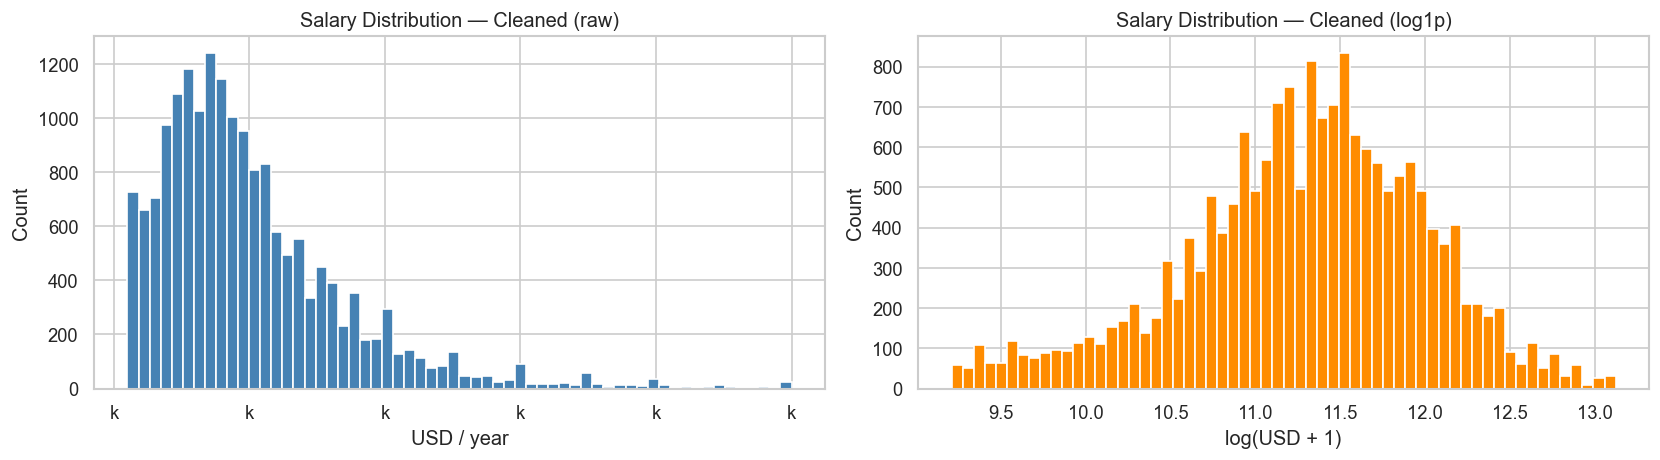

In [12]:
# Quick sanity plot — salary distribution after cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['ConvertedCompYearly'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Salary Distribution — Cleaned (raw)')
axes[0].set_xlabel('USD / year')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'k'))

log_sal = np.log1p(df['ConvertedCompYearly'])
axes[1].hist(log_sal, bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Salary Distribution — Cleaned (log1p)')
axes[1].set_xlabel('log(USD + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/salary_distribution_cleaned.png', bbox_inches='tight')
plt.show()

In [13]:
df.to_csv('../data/cleaned.csv', index=False)
print('Saved to data/cleaned.csv')
print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')

Saved to data/cleaned.csv
Rows: 17,679  |  Columns: 172


## Phase 3 Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Drop null salary | 49,191 → 23,947 rows (25,244 dropped) |
| 2 | Remove outliers < $10k or > $500k | 23,947 → 21,203 rows (2,744 dropped) |
| 3 | Filter to Employed only | 21,203 → 17,679 rows (freelancers/students/retired removed) |
| 4 | Cap WorkExp > 50 | 8 rows capped |
| 5 | Impute missing values | WorkExp → 12.0, YearsCode → 15.0 (medians); 7,328 categorical cells filled with "Unknown" |
| 6 | Drop duplicates | 0 duplicates found |
| 7 | Save |  — 17,679 rows × 172 columns |

**Cleaned salary stats:**
- Mean: $100,250 · Median: $83,792 · Std: $69,527
- Range: $10,000 – $500,000
- 25th pct: $52,207 · 75th pct: $130,000

**Missing values:** All 10 key columns at 0.0% after imputation.